# ERA5 Time-Series Analysis: Fast montly trend calculation using numpy

(not Statsmodels)

We use totalPrecipitation (tp): https://www.dropbox.com/scl/fi/kvqtett1d5alnx9sc97wg/ERA5_land_SouthAmerica_totalPrecipitation_monthly.nc?rlkey=t7rz7y9vpu3caxqh1tqjr6gzn&st=r66g9222&dl=0



When working with multi-decade climate datasets like ERA5, data is frequently partitioned into annual files to keep file sizes manageable. This notebook demonstrates an optimized pipeline to:

1. **Load and Combine:** Use `xarray` and `dask` to lazily concatenate years of data without filling up system RAM.
2. **De-seasononalize:** Calculate a daily rolling climatology and subtract it to isolate the climate anomaly signal.
3. **Mean Linear Regression:** Calculate the long-term trend of the mean signal.

## Use dask to compute all chunks

**Note that this code will also work for daily data**

Optimized code running through all chunks and performing regression on 2 cores (16 GB each core). If you have more memory available, you can run on more cores. We use 6 threads per core (this is for the lst-squared regression).

In [5]:
import glob
import os, time, warnings
import dask.array as da
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt

warnings.filterwarnings(action='ignore', message='Mean of empty slice')
np.errstate(invalid='ignore', divide='ignore')

# ==============================================================================
# 1. FIXED VECTORIZED WORKER FUNCTION
# ==============================================================================
def xarray_numpy_regression(ts_chunk):
    """Processes a 3D Xarray DataArray chunk (time, lat, lon) dynamically.

    Returns a 2D Xarray Dataset containing slope, p_value, and r_squared.
    """
    # 1. Grab dimensions of the current incoming chunk
    n_time = len(ts_chunk.valid_time)
    n_lat = len(ts_chunk.latitude)
    n_lon = len(ts_chunk.longitude)

    # 2. Extract underlying NumPy array values directly
    # Inside map_blocks, ts_chunk.values is already a regular NumPy array
    tp = ts_chunk.values

    # 3. Compute time vectors dynamically inside the chunk to ensure perfect alignment
    datevec = ts_chunk.valid_time.values
    month_vector = pd.to_datetime(datevec).month.values
    date_daily = np.arange(0, n_time, 1)

    # 4. Perform Climatology/Anomaly extraction inside the NumPy chunk
    anomalies = np.full(tp.shape, np.nan, dtype=np.float32)
    with warnings.catch_warnings():
        warnings.filterwarnings(
                "ignore", message="Mean of empty slice", category=RuntimeWarning
        )    
        for i in range(1, 13):
            month_indices = month_vector == i
            if not np.any(month_indices):
                continue
    
            # Isolate the data for that specific calendar month
            sub_matrix = tp[month_indices, :, :]
    
            # Calculate historical mean per pixel for this month
            month_mean = np.nanmean(sub_matrix, axis=0)
    
            # Subtract the mean
            anomalies[month_indices, :, :] = sub_matrix - month_mean

    # 5. Build Matrices for Linear Algebra
    # Design Matrix (Time, 2)
    A = np.vstack([date_daily, np.ones(n_time)]).T

    # Target Matrix flattened in spatial dimension -> Shape: (Time, Lat * Lon)
    Y = anomalies.reshape(n_time, n_lat * n_lon)

    # 6. Run the Least Squares regression simultaneously on all pixels
    coefficients, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)

    # Separate slopes and intercepts from the coefficients matrix
    # coefficients shape: (2, Lat * Lon) -> row 0 is slopes, row 1 is intercepts
    slopes_flat = coefficients[0, :]

    # 7. Compute R-Squared
    # (Time, 2) dot (2, Lat*Lon) -> Shape: (Time, Lat*Lon)
    y_pred = np.dot(A, coefficients)
    ss_res = np.sum((Y - y_pred) ** 2, axis=0)

    y_mean = np.mean(Y, axis=0)
    ss_tot = np.sum((Y - y_mean) ** 2, axis=0)

    # Safe Division for R²
    r_squared_flat = np.where(ss_tot > 0, 1.0 - (ss_res / ss_tot), np.nan)

    # 8. Compute P-Value via F-Statistic
    df = n_time - 2
    with np.errstate(invalid="ignore", divide="ignore"):
        f_stat = (r_squared_flat / (1.0 - r_squared_flat)) * df
        p_val_flat = 1.0 - stats.f.cdf(f_stat, 1, df)

    # 9. Reshape flat vectors back to the EXACT spatial dimensions of this chunk
    slopes = slopes_flat.reshape(n_lat, n_lon) * 365 * 1000
    r_squares = r_squared_flat.reshape(n_lat, n_lon)
    p_values = p_val_flat.reshape(n_lat, n_lon)

    # 10. Wrap back into a clean 2D Xarray Dataset
    chunk_result = xr.Dataset(
        data_vars={
            "slope": (["latitude", "longitude"], slopes),
            "p_value": (["latitude", "longitude"], p_values),
            "r_squared": (["latitude", "longitude"], r_squares),
        },
        coords={
            "latitude": ts_chunk.latitude,
            "longitude": ts_chunk.longitude,
        },
    )

    return chunk_result


# ==============================================================================
# 2. DASK PIPELINE INITIALIZATION
# ==============================================================================
if __name__ == "__main__":
    # Setup Data Directories
    data_dir = "./"
    file_pattern = os.path.join(data_dir, "ERA5_land_SouthAmerica_totalPrecipitation_monthly.nc")
    file_list = sorted(glob.glob(file_pattern))

    # Initialize Local Cluster
    cluster = LocalCluster(
        n_workers=2, threads_per_worker=6, memory_limit="16GB"
    )
    client = Client(cluster)
    print(f"Dask dashboard active at: {client.dashboard_link}")

    # Open multi-file datasets lazily with clean graph constraints
    ds = xr.open_mfdataset(
        file_list,
        combine="by_coords",
        parallel=True,
        coords="minimal",
        data_vars="minimal",
        compat="override",
    )

    # Chunk dataset cleanly (Time dimension MUST be unbroken (-1))
    ds = ds.chunk({"valid_time": -1, "latitude": 100, "longitude": 100})

    # Extract global dimensions and structural chunk footprints
    n_global_lat = len(ds.latitude)
    n_global_lon = len(ds.longitude)
    lat_chunks = ds["tp"].chunks[1]
    lon_chunks = ds["tp"].chunks[2]

    # Build Template with lazy Dask arrays matching spatial chunk blueprints
    template = xr.Dataset(
        data_vars={
            "slope": (
                ["latitude", "longitude"],
                da.empty(
                    (n_global_lat, n_global_lon),
                    chunks=(lat_chunks, lon_chunks),
                    dtype=float,
                ),
            ),
            "p_value": (
                ["latitude", "longitude"],
                da.empty(
                    (n_global_lat, n_global_lon),
                    chunks=(lat_chunks, lon_chunks),
                    dtype=float,
                ),
            ),
            "r_squared": (
                ["latitude", "longitude"],
                da.empty(
                    (n_global_lat, n_global_lon),
                    chunks=(lat_chunks, lon_chunks),
                    dtype=float,
                ),
            ),
        },
        coords={
            "latitude": ds.latitude,
            "longitude": ds.longitude,
        },
    )

    start = time.time()
    # Reset graph complexity by cleanly mapping your DataArray block execution
    output_ds = xr.map_blocks(
        xarray_numpy_regression, ds["tp"], template=template
    ).compute()    
    dask_parallel_trend_duration = time.time() - start
    print(f"Dask map_blocks with numpy regression: {dask_parallel_trend_duration:.2f} seconds or {dask_parallel_trend_duration/60:.2f} minutes!")

    # Stream computations directly to your file system
    print("Streaming calculations chunk-by-chunk directly to disk...")
    output_ds.to_netcdf("ERA5_SAM_monthly_tp_slope_r2_pvalue_regression_results.nc")
    print("Done! Check your working directory for ERA5_SAM_monthly_tp_slope_r2_pvalue_regression_results.nc")

/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46323 instead
  warnings.warn(


Dask dashboard active at: http://127.0.0.1:46323/status


/tmp/ipykernel_2266437/1378522537.py:51: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2266437/1378522537.py:51: RuntimeWarning: Mean of empty slice


Dask map_blocks with numpy regression: 2.62 seconds or 0.04 minutes!
Streaming calculations chunk-by-chunk directly to disk...
Done! Check your working directory for ERA5_SAM_monthly_tp_slope_r2_pvalue_regression_results.nc


In [6]:
output_ds

<xarray.Dataset> Size: 4MB
Dimensions:    (latitude: 501, longitude: 301)
Coordinates:
  * latitude   (latitude) float64 4kB 10.0 9.9 9.8 9.7 ... -39.8 -39.9 -40.0
  * longitude  (longitude) float64 2kB -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    number     int64 8B 0
Data variables:
    r_squared  (latitude, longitude) float64 1MB nan nan nan nan ... nan nan nan
    p_value    (latitude, longitude) float64 1MB nan nan nan nan ... nan nan nan
    slope      (latitude, longitude) float64 1MB nan nan nan nan ... nan nan nan

In [7]:
slope_per_decade = output_ds['slope']  # slope is already in mm/decade 

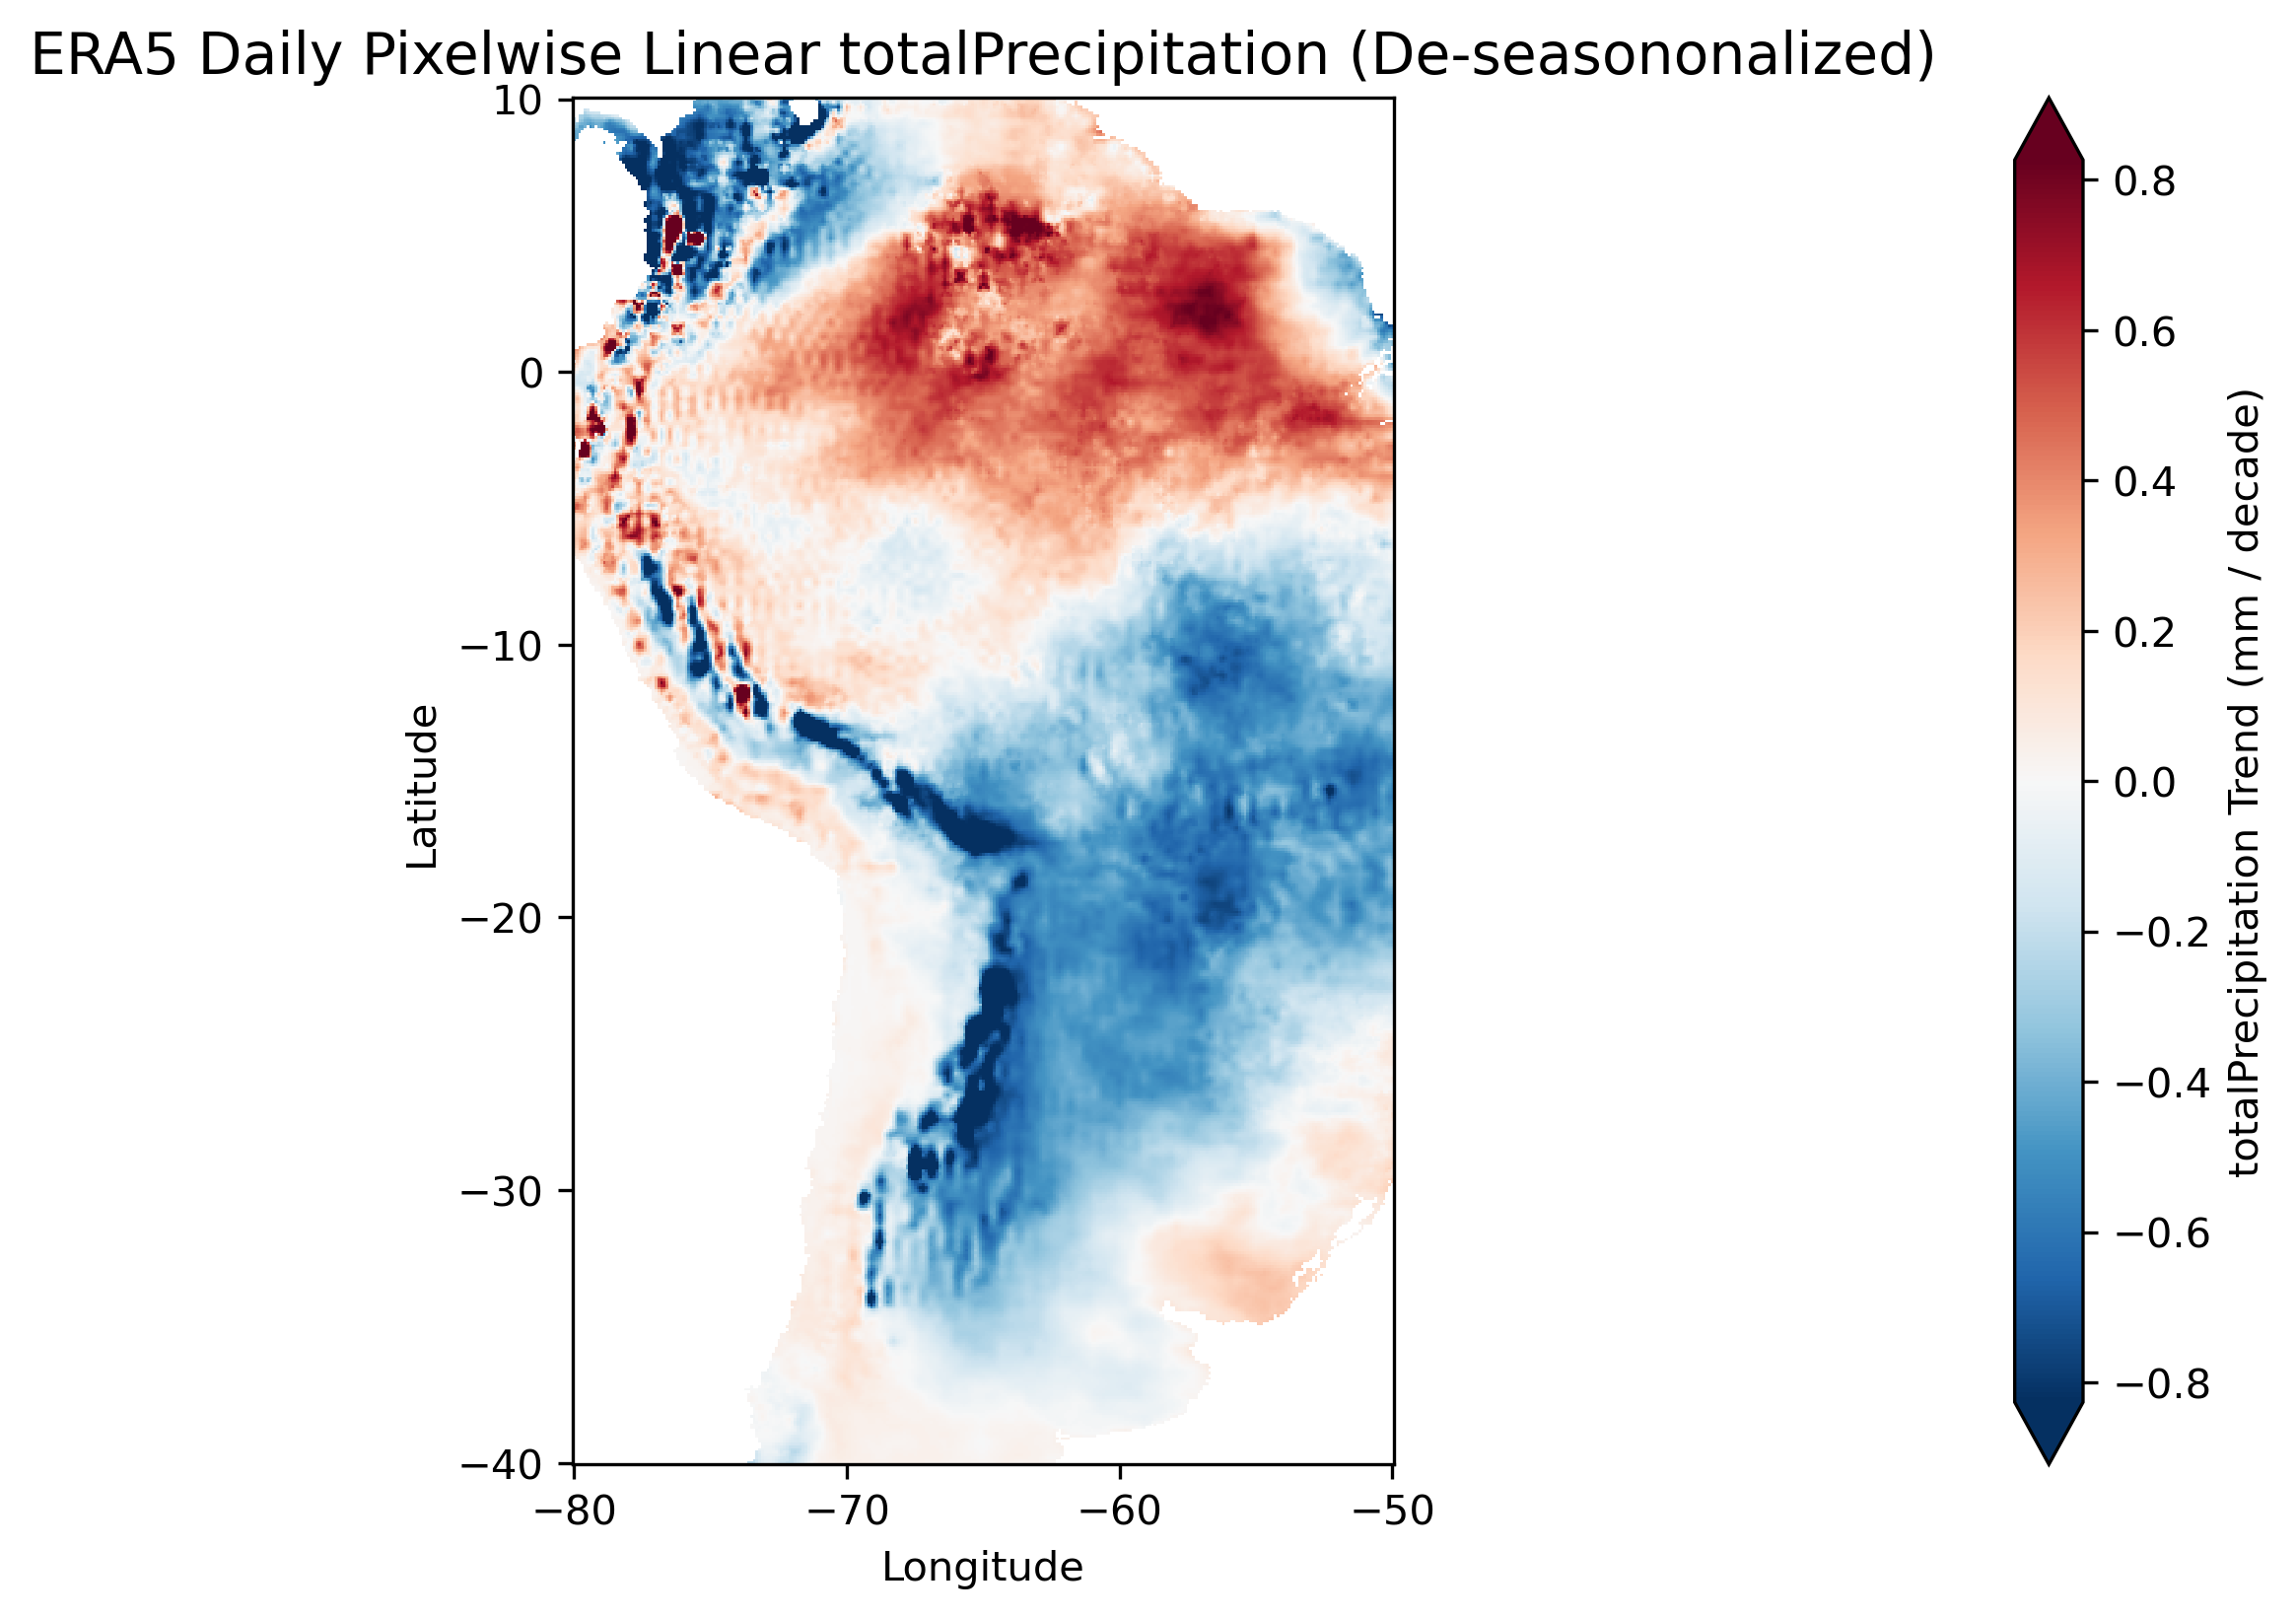

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6), dpi=300)
slope_per_decade.plot(
    cmap="RdBu_r", 
    robust=True, 
    cbar_kwargs={"label": "totalPrecipitation Trend (mm / decade)"}
)
plt.title("ERA5 Daily Pixelwise Linear totalPrecipitation (De-seasononalized)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('scaled')
plt.show()

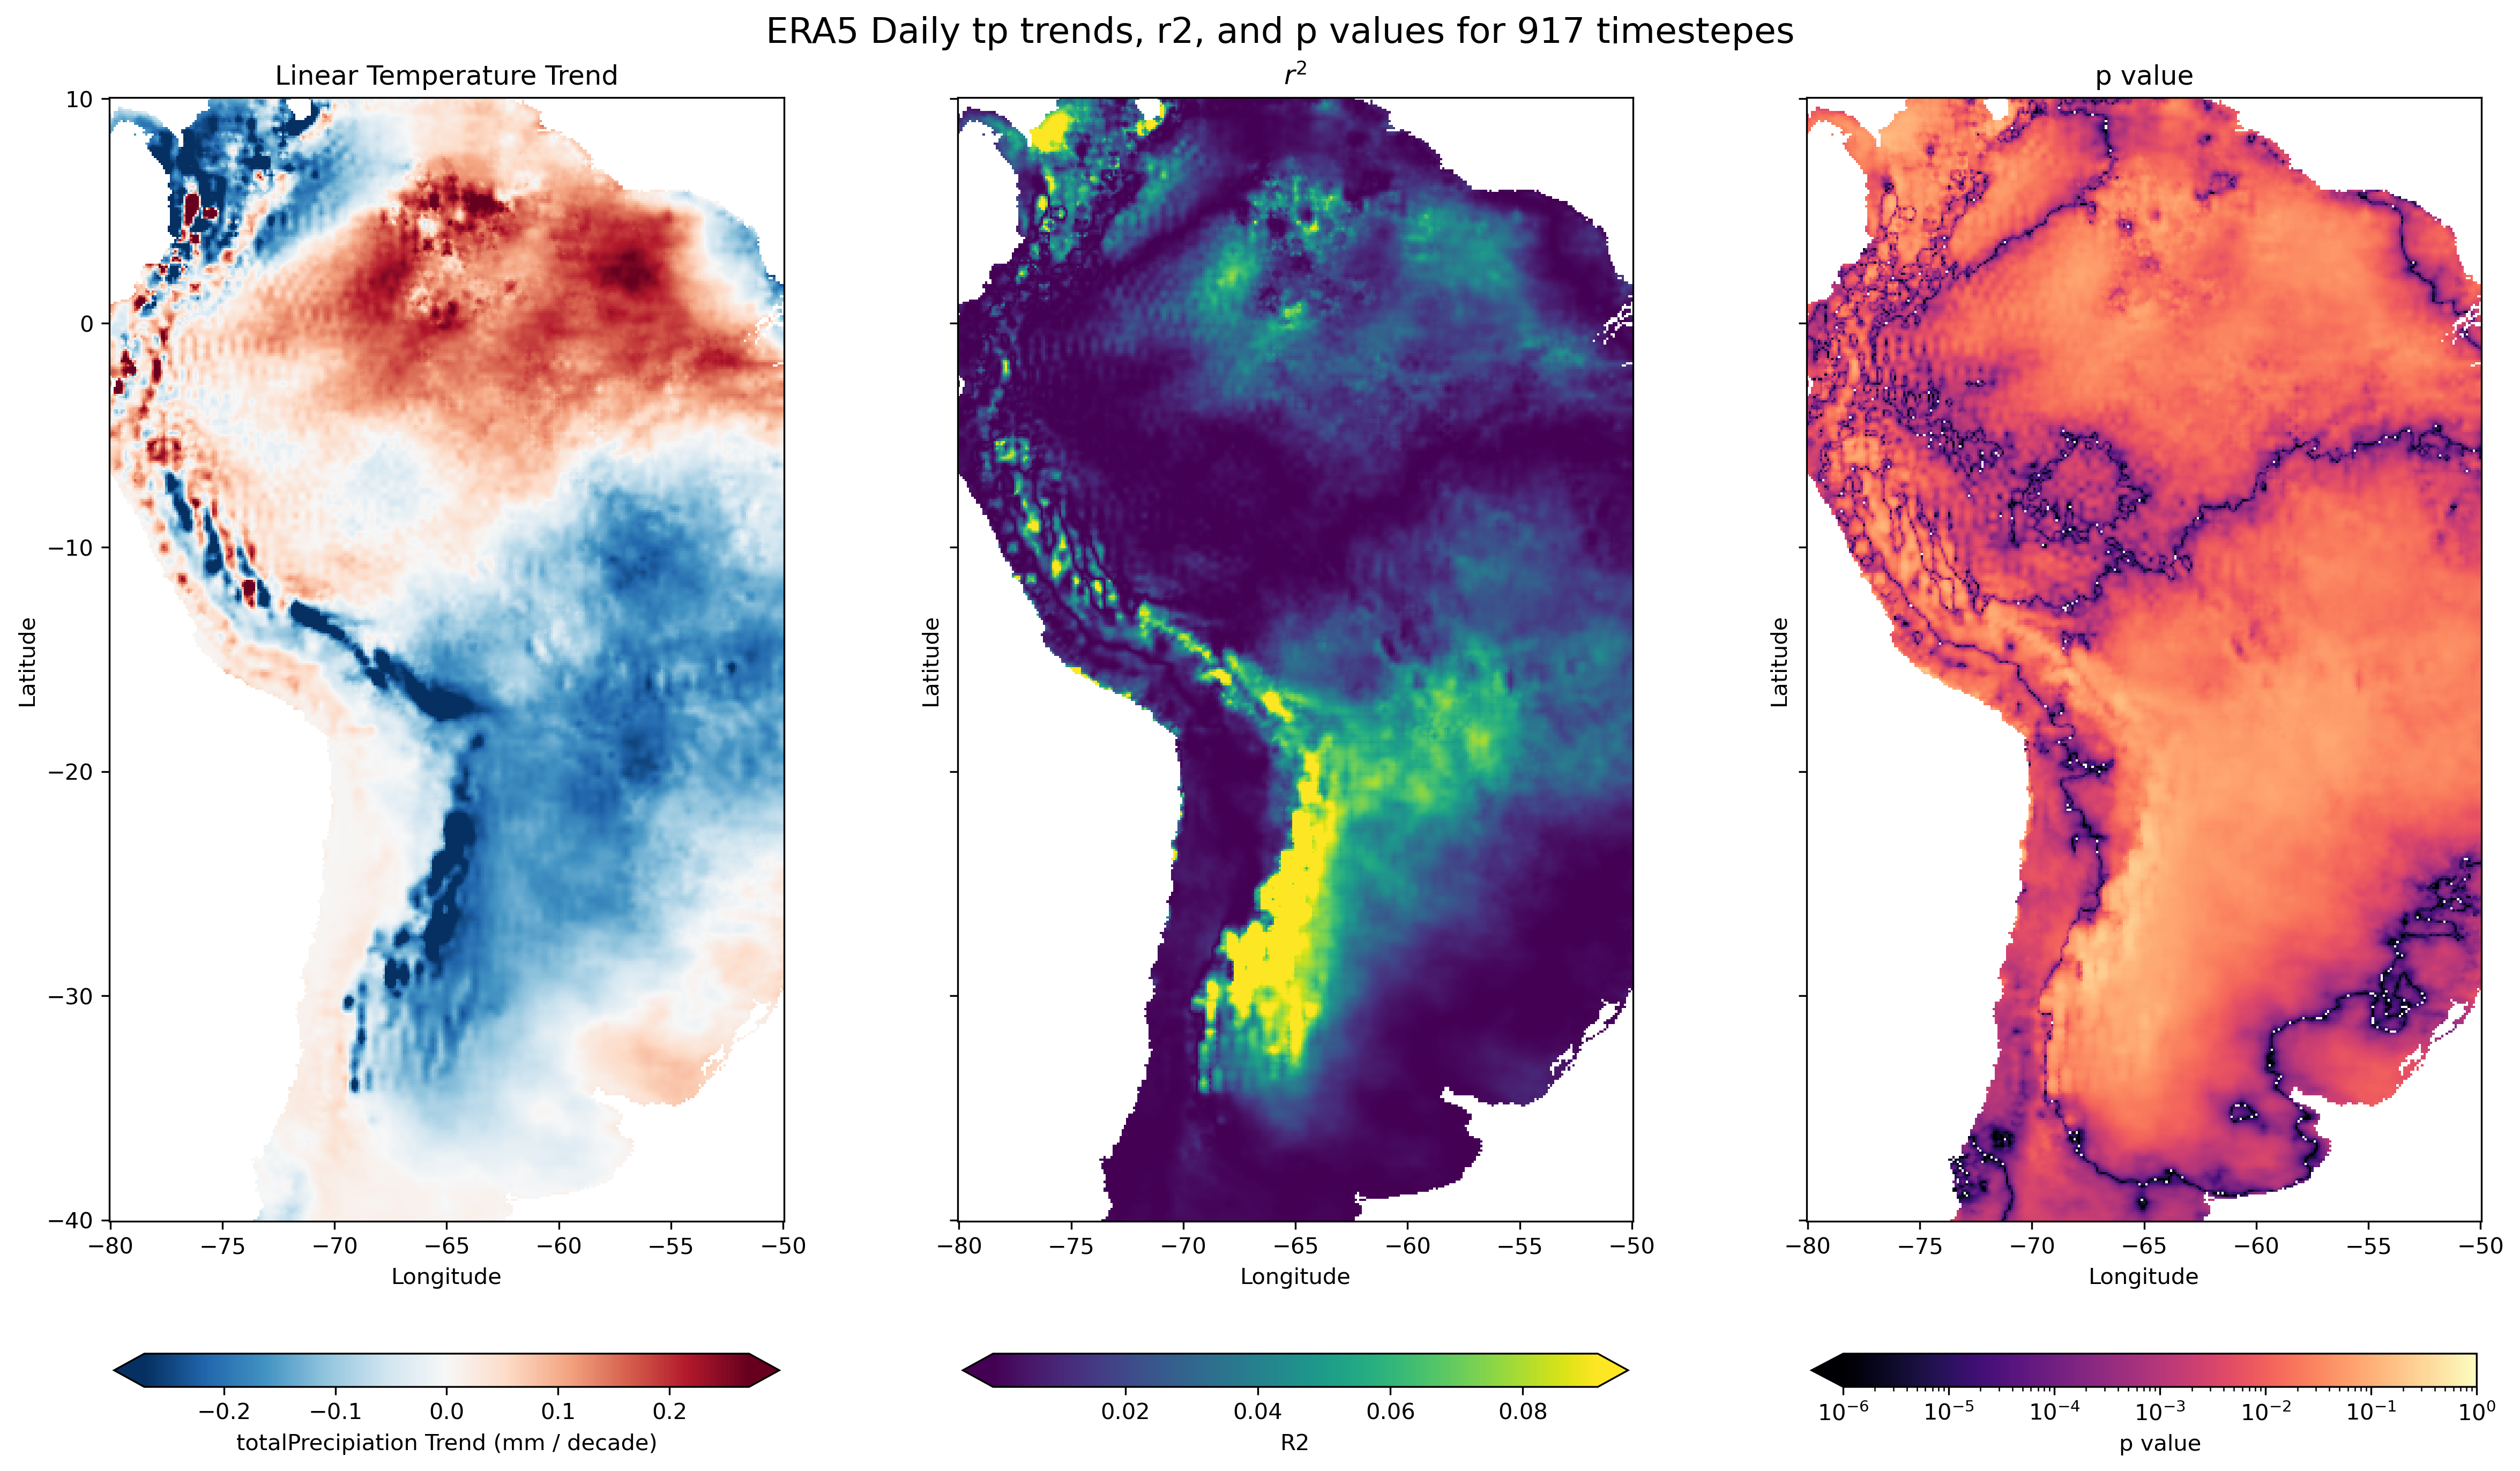

In [5]:
# Make a figure showing all attributes
import matplotlib.colors as colors

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,9), sharey=True, dpi=300, layout='constrained')

slope_per_decade.plot(
    cmap="RdBu_r", 
    robust=True, 
    cbar_kwargs={"label": "totalPrecipiation Trend (mm / decade)", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[0]
)
ax[0].set_title("Linear Temperature Trend", fontsize=12)
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_aspect('equal')

output_ds['r_squared'].plot(
    cmap="viridis", 
    robust=True, 
    cbar_kwargs={"label": "R2", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[1]
)
ax[1].set_title(r"$r^2$", fontsize=12)
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].set_aspect('equal')

output_ds['r_squared'].plot(
    cmap="magma", 
    robust=True,
    norm=colors.LogNorm(vmin=1e-6, vmax=1),
    cbar_kwargs={"label": "p value", 'shrink'
                 :0.8, 'orientation':'horizontal'},
    ax=ax[2]
)
ax[2].set_title(r"p value", fontsize=12)
ax[2].set_xlabel("Longitude")
ax[2].set_ylabel("Latitude")
ax[2].set_aspect('equal')

fig.suptitle('ERA5 Daily tp trends, r2, and p values for %s timestepes'%f'{ds['tp'].shape[0]:,}'   , fontsize=16)
fig.savefig('ERA5_daily_tp_1970_2025.png')

In [6]:
client.close()
cluster.close()